# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

# NB_P3_02 — DLCN Dataset Exploration

DLCN (Dynamic Lighting Conditions at Night) ships one HDF5 file per recording.
Before designing the unified Phase-3 preprocessing schema, this notebook
inventories what DLCN already provides, so its contents can be mapped into the
common schema alongside the other datasets.

## What is in the DLCN files?

Inventories the raw material without interpreting it yet: the directory layout,
how many recordings are present, any non-HDF5 metadata or label files, and the
complete internal structure (groups, datasets, shapes, dtypes, attributes) of a
single recording. The central questions for this step are whether each file
stores video frames or extracted signals, whether a respiration reference is
present directly, and where the sampling rates, units, and per-recording
metadata (subject, lighting scenario, rest/post-exercise state) live.

## Imports and Setup

In [14]:
from pathlib import Path
import h5py, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from numpy.fft import rfft, rfftfreq
DLCN_DIR = Path(r"G:\rppg\RPPG-DLCN")

print(f"DLCN root: {DLCN_DIR}  (exists={DLCN_DIR.exists()})")

print("\nTop-level entries:")
for entry in sorted(DLCN_DIR.iterdir())[:25]:
    print(f"  [{'dir ' if entry.is_dir() else 'file'}] {entry.name}")

h5_files = sorted(DLCN_DIR.rglob("*.h5"))
print(f"\nTotal .h5 files: {len(h5_files)}")
for p in h5_files[:10]:
    print(f"  {p.relative_to(DLCN_DIR)}  ({p.stat().st_size / 1e6:.1f} MB)")

other = [p for p in DLCN_DIR.rglob("*") if p.is_file() and p.suffix.lower() != ".h5"]
print(f"\nNon-.h5 files (possible labels / README / metadata): {len(other)}")
for p in other[:25]:
    print(f"  {p.relative_to(DLCN_DIR)}  ({p.stat().st_size / 1e3:.1f} KB)")

DLCN root: G:\rppg\RPPG-DLCN  (exists=True)

Top-level entries:
  [dir ] DLCN

Total .h5 files: 780
  DLCN\P10_1.h5  (54.6 MB)
  DLCN\P10_2.h5  (61.7 MB)
  DLCN\P10_3.h5  (51.5 MB)
  DLCN\P10_4.h5  (61.5 MB)
  DLCN\P10_5.h5  (55.7 MB)
  DLCN\P10_6.h5  (64.6 MB)
  DLCN\P10_7.h5  (53.4 MB)
  DLCN\P10_8.h5  (62.2 MB)
  DLCN\P11_1.h5  (55.4 MB)
  DLCN\P11_2.h5  (59.0 MB)

Non-.h5 files (possible labels / README / metadata): 0


In [2]:
def describe_h5(path, max_attr_chars=100):
    """Prints the complete structure of one HDF5 file: file-level attributes, then every
    group and dataset with its shape, dtype, and attributes."""
    def show_attrs(obj, indent):
        for key, val in obj.attrs.items():
            text = str(val)
            if len(text) > max_attr_chars:
                text = text[:max_attr_chars] + "..."
            print(f"{indent}    @{key} = {text}")

    with h5py.File(path, "r") as f:
        print(f"=== {path.name} ===")
        print("File-level attributes:")
        show_attrs(f, "")
        print("Tree:")

        def visitor(name, obj):
            indent = "  " * name.count("/")
            leaf = name.split("/")[-1]
            if isinstance(obj, h5py.Dataset):
                print(f"{indent}  {leaf}  [dataset]  shape={obj.shape}  dtype={obj.dtype}")
            else:
                print(f"{indent}  {leaf}/  [group]")
            show_attrs(obj, indent)

        f.visititems(visitor)


if h5_files:
    describe_h5(h5_files[0])
else:
    print("No .h5 files found — check the path.")

=== P10_1.h5 ===
File-level attributes:
Tree:
  bvp  [dataset]  shape=(1801,)  dtype=float64
  hr  [dataset]  shape=(60,)  dtype=float64
  imgs  [dataset]  shape=(1801, 128, 128, 3)  dtype=uint8
  spo2  [dataset]  shape=(60,)  dtype=float64


## Is the schema uniform across all 780 recordings?

Step above inspected a single file. This step scans every recording (reading only
metadata, not frame data) to confirm the field set is identical everywhere —
in particular that no subset carries a respiration channel absent from the
first file — and to extract the dataset's structural shape: participant count,
the distribution of the condition suffix, frame-count and image-shape
consistency, and reference-signal lengths. These are the facts the unified
Phase-3 schema and a DLCN loader will be built against.

In [5]:
schemas = Counter()
field_presence = Counter()
frame_counts, frame_shapes = [], Counter()
bvp_lengths, hr_lengths, spo2_lengths = Counter(), Counter(), Counter()
participants, cond_suffix = set(), Counter()

for p in h5_files:
    with h5py.File(p, "r") as f:
        keys = tuple(sorted(f.keys()))
        schemas[keys] += 1
        for k in keys:
            field_presence[k] += 1
        if "imgs" in f:
            frame_counts.append(f["imgs"].shape[0])
            frame_shapes[tuple(f["imgs"].shape[1:])] += 1
        if "bvp" in f:
            bvp_lengths[f["bvp"].shape[0]] += 1
        if "hr" in f:
            hr_lengths[f["hr"].shape[0]] += 1
        if "spo2" in f:
            spo2_lengths[f["spo2"].shape[0]] += 1
    stem = p.stem  # e.g. "P10_1"
    if stem.startswith("P") and "_" in stem:
        pid, cond = stem[1:].split("_", 1)
        participants.add(pid)
        cond_suffix[cond] += 1

print(f"Distinct top-level schemas across {len(h5_files)} files:")
for keys, n in schemas.most_common():
    print(f"  {n:4d} files: {keys}")

print(f"\nField presence: {dict(field_presence)}")
print(f"Unique participants: {len(participants)}")
print(f"Condition-suffix distribution: {dict(sorted(cond_suffix.items(), key=lambda x: int(x[0])))}")

fc = np.array(frame_counts)
print(f"\nFrame counts: min={fc.min()}  median={int(np.median(fc))}  max={fc.max()}  (n distinct={len(set(frame_counts))})")
print(f"Image shapes: {dict(frame_shapes)}")
print(f"bvp lengths: {dict(bvp_lengths)}")
print(f"hr lengths:  {dict(hr_lengths)}")
print(f"spo2 lengths:{dict(spo2_lengths)}")

Distinct top-level schemas across 780 files:
   780 files: ('bvp', 'hr', 'imgs', 'spo2')

Field presence: {'bvp': 780, 'hr': 780, 'imgs': 780, 'spo2': 780}
Unique participants: 98
Condition-suffix distribution: {'1': 98, '2': 98, '3': 98, '4': 98, '5': 97, '6': 97, '7': 97, '8': 97}

Frame counts: min=167  median=1801  max=1805  (n distinct=10)
Image shapes: {(128, 128, 3): 780}
bvp lengths: {1801: 468, 1802: 292, 1805: 13, 1655: 1, 1682: 1, 1796: 1, 167: 1, 1803: 1, 1800: 1, 1798: 1}
hr lengths:  {60: 668, 57: 8, 53: 9, 8: 1, 35: 2, 61: 23, 55: 12, 46: 5, 56: 6, 59: 7, 52: 3, 54: 1, 25: 2, 44: 1, 50: 2, 58: 3, 5: 1, 42: 1, 39: 1, 1: 1, 49: 4, 48: 2, 40: 2, 43: 3, 33: 1, 38: 2, 37: 1, 34: 1, 41: 3, 32: 1, 11: 1, 45: 1, 47: 1}
spo2 lengths:{60: 668, 57: 8, 53: 9, 8: 1, 35: 2, 61: 23, 55: 12, 46: 5, 56: 6, 59: 7, 52: 3, 54: 1, 25: 2, 44: 1, 50: 2, 58: 3, 5: 1, 42: 1, 39: 1, 1: 1, 49: 4, 48: 2, 40: 2, 43: 3, 33: 1, 38: 2, 37: 1, 34: 1, 41: 3, 32: 1, 11: 1, 45: 1, 47: 1}


## What does a single recording actually look like?

Loads one clean, full-length recording and inspects its content directly: the
BVP waveform (full and a 10 s zoom for pulse morphology), the 1 Hz HR and SpO2
reference, and a montage of sampled frames to confirm the face crop and see the
nighttime lighting. Also validates the sampling-rate assumption by deriving heart
rate from the BVP spectrum and comparing it against the reference HR - if the
video is ~30 fps and the reference is ~1 Hz, the two should agree.

File: P10_1.h5
n_frames=1801  len(hr)=60  -> assumed ~60s, fps≈30.02
bvp: len=1801  range=[9.52, 80]
hr:  mean=82.0  range=[78, 86] bpm
spo2: mean=96.1  range=[95, 97] %
BVP spectral peak = 80.0 bpm  vs  reference HR mean = 82.0 bpm


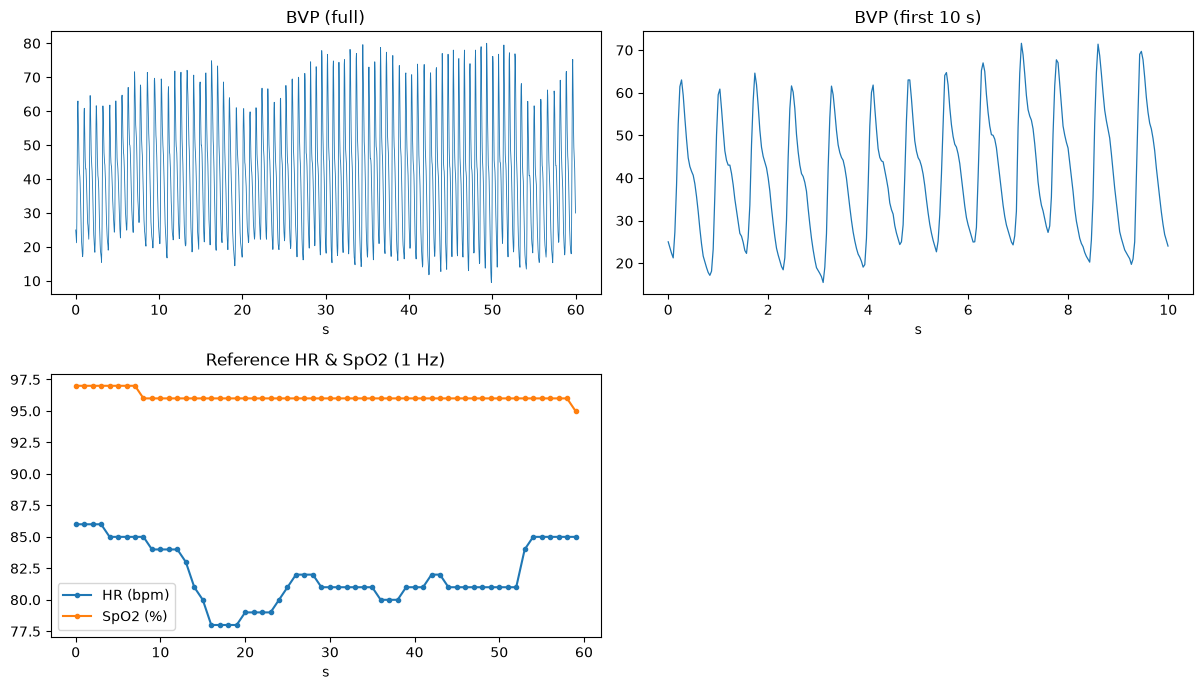

In [13]:
def find_clean_file(files, want_frames=1801, want_ref=60):
    """Returns the first recording whose frame count and reference length match the common case."""
    for p in files:
        with h5py.File(p, "r") as f:
            if f["imgs"].shape[0] == want_frames and f["hr"].shape[0] == want_ref:
                return p
    return files[0]

sample_path = find_clean_file(h5_files)
with h5py.File(sample_path, "r") as f:
    bvp = f["bvp"][:]
    hr = f["hr"][:]
    spo2 = f["spo2"][:]
    n_frames = f["imgs"].shape[0]
    idx = np.unique(np.linspace(0, n_frames - 1, 6).astype(int))
    frames = f["imgs"][idx]

duration_s = len(hr)                 # reference assumed at 1 Hz
fps_est = n_frames / duration_s
print(f"File: {sample_path.name}")
print(f"n_frames={n_frames}  len(hr)={len(hr)}  -> assumed ~{duration_s}s, fps≈{fps_est:.2f}")
print(f"bvp: len={len(bvp)}  range=[{bvp.min():.3g}, {bvp.max():.3g}]")
print(f"hr:  mean={hr.mean():.1f}  range=[{hr.min():.0f}, {hr.max():.0f}] bpm")
print(f"spo2: mean={spo2.mean():.1f}  range=[{spo2.min():.0f}, {spo2.max():.0f}] %")

sig = (bvp - bvp.mean()) * np.hanning(len(bvp))
power = np.abs(rfft(sig)) ** 2
freqs = rfftfreq(len(bvp), d=1.0 / fps_est)
band = (freqs >= 0.7) & (freqs <= 3.5)
peak_bpm = freqs[band][np.argmax(power[band])] * 60
print(f"BVP spectral peak = {peak_bpm:.1f} bpm  vs  reference HR mean = {hr.mean():.1f} bpm")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
t = np.arange(len(bvp)) / fps_est
axes[0, 0].plot(t, bvp, lw=0.6); axes[0, 0].set_title("BVP (full)"); axes[0, 0].set_xlabel("s")
z = t <= 10
axes[0, 1].plot(t[z], bvp[z], lw=0.9); axes[0, 1].set_title("BVP (first 10 s)"); axes[0, 1].set_xlabel("s")
tr = np.arange(len(hr))
axes[1, 0].plot(tr, hr, ".-", label="HR (bpm)")
axes[1, 0].plot(tr, spo2, ".-", label="SpO2 (%)")
axes[1, 0].set_title("Reference HR & SpO2 (1 Hz)"); axes[1, 0].set_xlabel("s"); axes[1, 0].legend()
axes[1, 1].axis("off")
plt.tight_layout(); plt.show()

# fig, axes = plt.subplots(1, len(idx), figsize=(15, 3))
# for ax, fr, i in zip(axes, frames, idx):
#     ax.imshow(fr); ax.set_title(f"frame {i}"); ax.axis("off")
# plt.suptitle(f"{sample_path.name} — sampled frames"); plt.tight_layout(); plt.show()

## Decode the eight conditions (lighting and state)

DLCN encodes each recording as `P{id}_{1..8}` with no stored metadata, so the
meaning of the eight conditions must be recovered from the data. This step
triangulates it: a montage of one mid-frame per condition for a single
participant to see the lighting scenarios directly, mean frame brightness per
condition across a participant sample to quantify them, and mean reference HR
per condition to expose the resting vs post-exercise structure (post-exercise
recordings should run at elevated HR). If brightness clusters into a few levels
and HR separates into two groups, that would confirm a lighting x state design.

In [18]:
by_pid = {}
for p in h5_files:
    m = re.match(r"P(\d+)_(\d+)$", p.stem)
    if m:
        pid, cond = m.group(1), int(m.group(2))
        by_pid.setdefault(pid, {})[cond] = p

pids_sorted = sorted(by_pid, key=int)
print(f"Participants: {len(pids_sorted)}")
for pid in pids_sorted[:5]:
    print(f"  P{pid}: conditions {sorted(by_pid[pid])}")

# (a) One mid-frame per condition for a single participant
demo_pid = pids_sorted[0]
conds = sorted(by_pid[demo_pid])
# fig, axes = plt.subplots(1, len(conds), figsize=(2.2 * len(conds), 2.6))
# for ax, c in zip(np.atleast_1d(axes), conds):
#     with h5py.File(by_pid[demo_pid][c], "r") as f:
#         ax.imshow(f["imgs"][f["imgs"].shape[0] // 2])
#     ax.set_title(f"cond {c}"); ax.axis("off")
# plt.suptitle(f"P{demo_pid} — one mid-frame per condition"); plt.tight_layout(); plt.show()

# (b,c) Brightness and mean HR per condition across a participant sample
sample_pids = pids_sorted[:25]
bright_by_cond = {c: [] for c in range(1, 9)}
hr_by_cond = {c: [] for c in range(1, 9)}
for pid in sample_pids:
    for c, path in by_pid[pid].items():
        with h5py.File(path, "r") as f:
            bright_by_cond[c].append(float(f["imgs"][f["imgs"].shape[0] // 2].mean()))
            hr = f["hr"][:]
            if len(hr):
                hr_by_cond[c].append(float(np.mean(hr)))

print(f"\nPer-condition summary (mean over {len(sample_pids)} participants):")
print(f"{'cond':>4} {'mean_brightness':>16} {'mean_HR_bpm':>12} {'n':>4}")
for c in range(1, 9):
    b = np.mean(bright_by_cond[c]) if bright_by_cond[c] else float("nan")
    h = np.mean(hr_by_cond[c]) if hr_by_cond[c] else float("nan")
    print(f"{c:>4} {b:>16.1f} {h:>12.1f} {len(bright_by_cond[c]):>4}")

Participants: 98
  P1: conditions [1, 2, 3, 4, 5, 6, 7, 8]
  P2: conditions [1, 2, 3, 4, 5, 6, 7, 8]
  P3: conditions [1, 2, 3, 4, 5, 6, 7, 8]
  P4: conditions [1, 2, 3, 4, 5, 6, 7, 8]
  P5: conditions [1, 2, 3, 4, 5, 6, 7, 8]

Per-condition summary (mean over 25 participants):
cond  mean_brightness  mean_HR_bpm    n
   1             50.8         81.6   25
   2             81.3         84.3   25
   3             39.0         85.1   25
   4             67.0         85.9   25
   5             47.6         90.5   25
   6             79.0         95.4   25
   7             39.7         97.7   25
   8             65.3         94.8   25


## DLCN — exploration summary (schema card)

**Contents.** 780 recordings, 98 participants x 8 conditions (4 lighting
scenarios x 2 states). Each `P{id}_{cond}.h5` holds exactly four datasets and
no attributes:

| field | shape | rate | notes |
|-------|-------|------|-------|
| `imgs` | [T, 128, 128, 3] uint8 | ~30 fps | face-cropped RGB frames (natural skin tone -> RGB, not BGR) |
| `bvp`  | [T] float64 | ~30 Hz | frame-synced pulse waveform; clean pleth with visible dicrotic notch |
| `hr`   | [~60] float64 | 1 Hz | reference heart rate |
| `spo2` | [~60] float64 | 1 Hz | reference SpO2 (95-97% typical) |

**Condition decode (from data, not metadata).** Brightness pairs {1,5},{2,6},
{3,7},{4,8} = four lighting scenarios; HR is ~84 bpm for conditions 1-4 (rest)
vs ~95 bpm for 5-8 (post-exercise). fps ~30 confirmed by matching the BVP
spectral peak (80 bpm) to reference HR (82 bpm).

**Ground truth.** Fingertip-oximeter style: pulse waveform + HR + SpO2.
**No respiration channel and no ECG anywhere** (schema is 100% uniform across
all 780 files).

**Data-quality notes.** Frame counts vary (mostly 1801-1802, one truncated at
167); ~14% of recordings have short/dropped HR & SpO2 references. All metadata
(subject, condition, lighting, state) lives in the filename only, so fps must be
set explicitly to 30 and a validity/SQI flag is needed per recording.

**Role in Phase 3.** A frame-level, low-light HR/BVP (+SpO2) dataset. It feeds
the HR head (frames + frame-synced BVP + HR reference) and is an excellent
held-out nighttime robustness set. It contributes nothing to the RR head
(no respiration reference), so under a unified schema its recordings carry HR/
SpO2 labels present and RR masked — the first concrete instance of the
optional-label design.

## Quality / validity pass

Quantifies how many of the 780 recordings are cleanly usable and defines the
per-recording validity criteria that will become the schema's validity/SQI
flag. Each recording is checked on duration adequacy, reference completeness
(HR/SpO2 spanning the video), physiological plausibility of HR and SpO2, BVP
cardiac signal quality (spectral SQI) and its agreement with the reference HR,
and a light frame-integrity check (not black or blown out). Results are also
grouped by condition to see whether quality tracks the lighting scenarios.
Thresholds here are first-pass and meant to be calibrated from the resulting
distributions, not treated as final.

In [19]:
FPS = 30.0

def cardiac_metrics(bvp, fps, low=0.7, high=3.5):
    """Returns (hr_bpm, sqi) from a BVP waveform: the cardiac-band spectral peak in bpm and
    the 3-bin neighborhood fraction of in-band power at that peak, used as a quality index."""
    x = np.asarray(bvp, dtype=np.float64)
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan, 0.0
    x = (x - x.mean()) * np.hanning(x.size)
    power = np.abs(np.fft.rfft(x)) ** 2
    freqs = np.fft.rfftfreq(x.size, d=1.0 / fps)
    band = (freqs >= low) & (freqs <= high)
    if not band.any() or power[band].sum() <= 0:
        return np.nan, 0.0
    bp = power[band]
    pk = int(np.argmax(bp))
    hr_bpm = freqs[band][pk] * 60.0
    sqi = bp[max(0, pk - 1):pk + 2].sum() / bp.sum()
    return hr_bpm, float(sqi)

rows = []
for p in h5_files:
    with h5py.File(p, "r") as f:
        n = f["imgs"].shape[0]
        bvp = f["bvp"][:]
        hr = f["hr"][:]
        spo2 = f["spo2"][:]
        mid = f["imgs"][n // 2]
    dur = n / FPS
    bvp_hr, sqi = cardiac_metrics(bvp, FPS)
    ref_hr = float(np.mean(hr)) if len(hr) else np.nan
    spo2_mean = float(np.mean(spo2)) if len(spo2) else np.nan
    rows.append(dict(
        name=p.stem, cond=int(p.stem.split("_")[-1]), n=n, dur=dur, ref_len=len(hr),
        sqi=sqi, bvp_hr=bvp_hr, ref_hr=ref_hr, spo2=spo2_mean, bright=float(mid.mean()),
        dur_ok=dur >= 20,
        ref_complete=len(hr) >= 0.9 * dur,
        hr_in_range=np.isfinite(ref_hr) and 40 <= ref_hr <= 180,
        spo2_in_range=np.isfinite(spo2_mean) and 70 <= spo2_mean <= 100,
        frame_ok=5 <= float(mid.mean()) <= 250,
        hr_consistent=np.isfinite(bvp_hr) and np.isfinite(ref_hr) and abs(bvp_hr - ref_hr) <= 10,
    ))

df = pd.DataFrame(rows)
df["valid"] = (df.dur_ok & df.ref_complete & df.hr_in_range & df.spo2_in_range
               & df.frame_ok & (df.sqi >= 0.10) & df.hr_consistent)
print(f"Scanned {len(df)} recordings.")

Scanned 780 recordings.


Valid on all checks: 656 / 780  (84.1%)

Recordings failing each individual check:
  duration >= 20 s          :   1 fail
  reference spans video     :  53 fail
  HR 40-180 bpm             :   0 fail
  SpO2 70-100 %             :   0 fail
  frame not black/blown     :   2 fail
  BVP vs ref HR <= 10 bpm   :  76 fail
  cardiac SQI >= 0.10       :   0 fail

SQI percentiles:
  p0=0.10  p5=0.19  p25=0.29  p50=0.40  p75=0.53  p95=0.70  p100=0.81

By condition (mean SQI, valid-rate, mean brightness):
      mean_sqi  valid_rate  mean_bright   n
cond                                       
1        0.446       0.959       46.870  98
2        0.470       0.980       72.133  98
3        0.469       0.980       38.924  98
4        0.439       0.959       66.689  98
5        0.353       0.753       45.969  97
6        0.396       0.732       73.693  97
7        0.354       0.680       37.909  97
8        0.376       0.680       67.659  97

Worst 10 by SQI:
 name    n  ref_len  sqi  bvp_hr  ref_hr  b

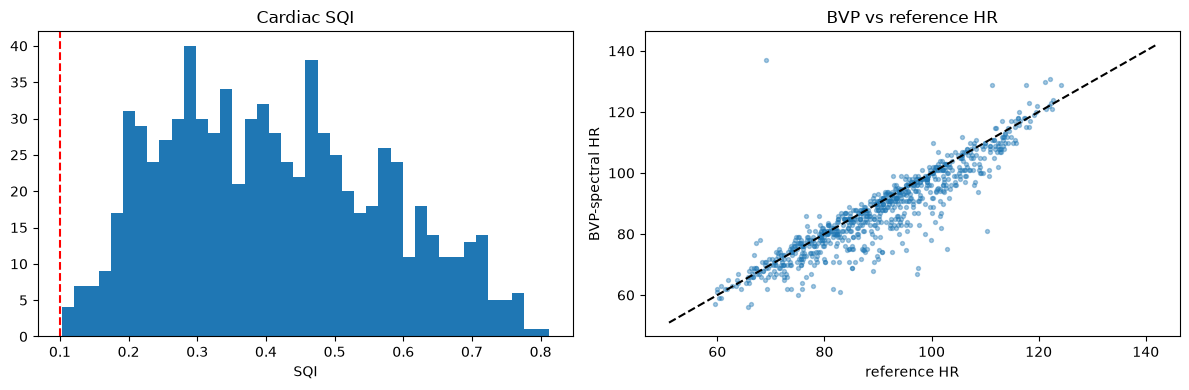

In [20]:
print(f"Valid on all checks: {df.valid.sum()} / {len(df)}  ({df.valid.mean():.1%})\n")

print("Recordings failing each individual check:")
checks = [("dur_ok", "duration >= 20 s"), ("ref_complete", "reference spans video"),
          ("hr_in_range", "HR 40-180 bpm"), ("spo2_in_range", "SpO2 70-100 %"),
          ("frame_ok", "frame not black/blown"), ("hr_consistent", "BVP vs ref HR <= 10 bpm")]
for col, label in checks:
    print(f"  {label:26s}: {int((~df[col]).sum()):3d} fail")
print(f"  {'cardiac SQI >= 0.10':26s}: {int((df.sqi < 0.10).sum()):3d} fail")

print("\nSQI percentiles:")
print("  " + "  ".join(f"p{q}={np.percentile(df.sqi, q):.2f}" for q in [0, 5, 25, 50, 75, 95, 100]))

print("\nBy condition (mean SQI, valid-rate, mean brightness):")
print(df.groupby("cond").agg(mean_sqi=("sqi", "mean"),
                             valid_rate=("valid", "mean"),
                             mean_bright=("bright", "mean"),
                             n=("name", "size")).round(3).to_string())

print("\nWorst 10 by SQI:")
print(df.nsmallest(10, "sqi")[["name", "n", "ref_len", "sqi", "bvp_hr", "ref_hr", "bright"]].round(2).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df.sqi, bins=40); ax[0].axvline(0.10, color="r", ls="--"); ax[0].set_title("Cardiac SQI"); ax[0].set_xlabel("SQI")
ax[1].scatter(df.ref_hr, df.bvp_hr, s=8, alpha=0.4)
lims = [df[["ref_hr", "bvp_hr"]].min().min() - 5, df[["ref_hr", "bvp_hr"]].max().max() + 5]
ax[1].plot(lims, lims, "k--"); ax[1].set_xlabel("reference HR"); ax[1].set_ylabel("BVP-spectral HR"); ax[1].set_title("BVP vs reference HR")
plt.tight_layout(); plt.show()

## Quality pass: findings

- Strict all-checks validity is 84% (656/780), but the losses are driven by
  STATE, not lighting: rest conditions 1-4 are ~96-98% valid, post-exercise 5-8
  are ~68-75%. The darkest scenario (condition 3) is 98% valid — low light does
  not degrade cardiac SQI here.
- The dominant failure (BVP vs reference-HR, 76 recordings) is confounded with
  HR non-stationarity during recovery: a single spectral HR over 60 s cannot
  match a drifting reference even for clean signal. It flags physiology, not
  corruption.
- The 1 Hz HR/SpO2 reference drops out in 53 recordings, but the frame-synced
  BVP is full-length and clean regardless. Cardiac SQI is healthy (median 0.40,
  p95 0.70); only ~3 recordings are truly corrupt (1 truncated, 2 bad frames).

Design implication: for a frame-synced BVP-waveform target, ~99% of DLCN is
usable. Store SQI, reference-completeness, and state as graded fields; use SQI
as a soft training weight rather than a hard gate; hard-exclude only true
corruption; and keep the post-exercise recordings for their elevated-HR range.

In [21]:
drift = []
for p in h5_files:
    with h5py.File(p, "r") as f:
        hr = f["hr"][:]
    drift.append(float(hr.max() - hr.min()) if len(hr) > 1 else np.nan)
df["hr_drift"] = drift
df["state"] = np.where(df.cond <= 4, "rest", "post-ex")

print(df.groupby("state").agg(
    n=("name", "size"), valid_rate=("valid", "mean"),
    consistency_fail=("hr_consistent", lambda s: (~s).mean()),
    mean_hr_drift=("hr_drift", "mean")).round(3).to_string())

print("\nMean HR drift, consistency pass vs fail:")
print(df.groupby("hr_consistent")["hr_drift"].mean().round(2).to_string())

           n  valid_rate  consistency_fail  mean_hr_drift
state                                                    
post-ex  388       0.711             0.170         26.067
rest     392       0.969             0.026         10.546

Mean HR drift, consistency pass vs fail:
hr_consistent
False    30.12
True     16.99


## Exploration conclusion

The HR-consistency failures are confirmed as physiological non-stationarity, not
corruption: consistency-fail recordings average 30 bpm of within-recording HR
drift vs 17 for passes, and post-exercise carries ~26 bpm drift (71% strict-valid)
vs ~10.5 bpm at rest (97%).

**DLCN, characterized.** 780 recordings, 98 participants x (4 lighting scenarios
x 2 states). 128x128 RGB frames (~30 fps, ~60 s), frame-synced clean BVP, plus
1 Hz HR and SpO2 references. No respiration channel and no ECG. Low light does
not degrade cardiac SQI.

**Role in Phase 3.** A frame-level HR/BVP (+SpO2) dataset and a strong held-out
nighttime robustness set. It feeds the HR head via the BVP waveform; it does not
contribute to the RR head (RR masked). ~99% is usable for a BVP-waveform target;
SQI is stored as a soft weight, the HR-drift flag as metadata, and only ~3
corrupt files are excluded. Post-exercise recordings are retained.

This is the first dataset mapped into the unified Phase-3 schema.